In [7]:
import numpy as np
import os
import re
from scipy.optimize import minimize
from gaussian_residues import gaussian_residues
from paraboloid_residues import paraboloid_residues
from RBF_residues import RBF_residues

np.set_printoptions(precision=4, suppress=True, linewidth=120)

path_to_variant_filenames = './варианты'

variant_filenames = [
    os.path.join(root, name)
    for root, dirs, files in os.walk(path_to_variant_filenames)
    for name in files
    if name.endswith(('.py')) and "11" in name
]
variant_filenames

for variant_filename in variant_filenames:
    # имя файла с заготовкой для студента (конкретный вариант)
    data = None # данные по варианту будут извлечены из файла .py
    
    try:
        with open(variant_filename, 'r',encoding='utf-8') as file:
            for line_number, line in enumerate(file, 1): 
                if 'data = np.array([' in line:
                    strs = ''.join([file.readline().strip() for idx in range(5)])
                    data = eval('np.array(['+strs+'])')
                    break
    except Exception as e:
        print(f"An error occurred for {variant_filename}. {e}")
    
    print("="*70)
    variant_int = re.findall(r'\d+', variant_filename)[0]
    print(f"VARIANT: {variant_int}")
    print("="*70)
    if not(data is None):
        gaussian_residues(data)
        
        

VARIANT: 11

Gaussian Model: z(x,y) = 5.0059 * exp(-Q) + 0.1295
Where Q = (x - 2.6189)² / (2 * 1.2716²) + (y - 2.8407)² / (2 * 1.1275²)

With rotation: θ = 1.28°
Note: Coordinates are rotated before applying the Gaussian
Sample   x    y    Actual   Predicted  Error    SqError   
--------------------------------------------------
0        0.85 1.12 0.73     0.730      -0.000   0.000     
1        1.83 2.20 3.65     3.650      0.000    0.000     
2        2.91 3.12 4.86     4.860      0.000    0.000     
3        3.93 3.92 2.00     2.000      0.000    0.000     
4        4.86 4.94 0.32     0.320      -0.000   0.000     


In [8]:
paraboloid_residues(data)


Paraboloid Model: z(x,y) = 8.8692
         + -3.3967·(x - 3.9255)²
         + -1.5166·(y - 6.0000)²
         + 2·2.0000·(x - 3.9255)(y - 6.0000)
Sample   x    y    Actual   Predicted  Error    SqError   
--------------------------------------------------------------------------------
0        0.85 1.12 0.73     0.659      -0.071   0.005     
1        1.83 2.20 3.65     3.907      0.257    0.066     
2        2.91 3.12 4.86     4.486      -0.374   0.140     
3        3.93 3.92 2.00     2.271      0.271    0.073     
4        4.86 4.94 0.32     0.237      -0.083   0.007     


In [9]:
RBF_residues(data)


RBF-net Model: z(x,y) = 0.1058 + 
    2.7715 * exp(-((x1-2.5082)^2 + (x2-2.7985)^2) / (2*1.1862^2)) + 
    2.2831 * exp(-((x1-2.7098)^2 + (x2-2.9521)^2) / (2*1.2339^2)) + 
Sample   x    y    Actual   Predicted  Error    SqError   
--------------------------------------------------------------------------------
0        0.85 1.12 0.73     0.733      0.003    0.000     
1        1.83 2.20 3.65     3.649      -0.001   0.000     
2        2.91 3.12 4.86     4.861      0.001    0.000     
3        3.93 3.92 2.00     1.999      -0.001   0.000     
4        4.86 4.94 0.32     0.319      -0.001   0.000     


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Set random seed for reproducibility
np.random.seed(42)

class KMeansScratch:
    """K-Means clustering algorithm implemented from scratch using numpy."""
    def __init__(self, n_clusters=2, max_iters=100):
        self.n_clusters = n_clusters
        self.max_iters = max_iters
        self.centroids = None
    
    def _euclidean_distance(self, X, centroids):
        """Compute Euclidean distance between X and centroids."""
        # X: (N, 2), Centroids: (K, 2)
        # Returns: (N, K)
        distances = np.zeros((X.shape[0], centroids.shape[0]))
        for k in range(centroids.shape[0]):
            diff = X - centroids[k]
            distances[:, k] = np.sqrt(np.sum(diff ** 2, axis=1))
        return distances
    
    def fit(self, X):
        """Fit K-Means to data X."""
        print("--- Starting K-Means Initialization ---")
        # Initialize centroids randomly from data points
        indices = np.array([0,2])#np.random.choice(X.shape[0], self.n_clusters, replace=False)
        self.centroids = X[indices].copy()
        
        for i in range(self.max_iters):
            # 1. Assign clusters
            distances = self._euclidean_distance(X, self.centroids)
            labels = np.argmin(distances, axis=1)
            
            # 2. Update centroids
            new_centroids = np.zeros_like(self.centroids)
            for k in range(self.n_clusters):
                cluster_points = X[labels == k]
                if len(cluster_points) > 0:
                    new_centroids[k] = cluster_points.mean(axis=0)
                else:
                    new_centroids[k] = self.centroids[k]
            
            # Check convergence
            shift = np.sqrt(np.sum((new_centroids - self.centroids) ** 2))
            self.centroids = new_centroids
            
            print(f"K-Means Iter {i+1}: Centroid Shift = {shift:.6f}")
            print(f"  Centers: {self.centroids}")
            
            if shift < 1e-4:
                print("K-Means Converged.")
                break
        return self.centroids

class RBFNetwork:
    """RBF Neural Network with Gradient Descent for all parameters."""
    def __init__(self, n_hidden=2, lr=0.01, epochs=500):
        self.n_hidden = n_hidden
        self.lr = lr
        self.epochs = epochs
        self.centers = None
        self.widths = None
        self.weights = None
        self.bias = None
        self.history = []
    
    def _gaussian(self, X, center, width):
        """Calculate Gaussian RBF activation."""
        diff = X - center
        dist_sq = np.sum(diff ** 2, axis=1)
        return np.exp(-dist_sq / (2 * width ** 2))
    
    def initialize(self, X):
        """Initialize centers using K-Means, widths using heuristic, weights randomly."""
        kmeans = KMeansScratch(n_clusters=self.n_hidden)
        self.centers = kmeans.fit(X)
        
        # Initialize widths: average distance between centers
        dist_between_centers = np.sqrt(np.sum((self.centers[0] - self.centers[1])**2))
        self.widths = np.array([dist_between_centers, dist_between_centers]) * 0.5
        self.widths = np.maximum(self.widths, 0.1) # Prevent division by zero
        
        # Initialize weights and bias
        self.weights = np.random.randn(self.n_hidden) * 0.5
        self.bias = 0.0
        
        print("\n--- Initialization Complete ---")
        print(f"Centers (c): {self.centers}")
        print(f"Widths (sigma): {self.widths}")
        print(f"Weights (w): {self.weights}")
        print(f"Bias (b): {self.bias}")

    def forward(self, X):
        """Forward pass."""
        activations = np.zeros((X.shape[0], self.n_hidden))
        for j in range(self.n_hidden):
            activations[:, j] = self._gaussian(X, self.centers[j], self.widths[j])
        output = np.dot(activations, self.weights) + self.bias
        return output, activations
    
    def train(self, X, y):
        """Train using Gradient Descent."""
        print("\n--- Starting Supervised Training (Gradient Descent) ---")
        N = X.shape[0]
        
        for epoch in range(self.epochs):
            # 1. Forward Pass
            y_pred, activations = self.forward(X)
            error = y_pred - y
            loss = np.mean(error ** 2)
            
            # Record history
            if epoch < 5 or epoch % 100 == 0 or epoch == self.epochs - 1:
                self.history.append({
                    'epoch': epoch,
                    'loss': loss,
                    'centers': self.centers.copy(),
                    'widths': self.widths.copy(),
                    'weights': self.weights.copy(),
                    'bias': self.bias
                })
            
            # 2. Backward Pass (Gradients)
            grad_w = np.zeros(self.n_hidden)
            grad_b = 0.0
            grad_sigma = np.zeros(self.n_hidden)
            grad_c = np.zeros_like(self.centers)
            
            # Calculate gradients summing over all samples
            for i in range(N):
                for j in range(self.n_hidden):
                    phi = activations[i, j]
                    diff = X[i] - self.centers[j]
                    dist_sq = np.sum(diff ** 2)
                    
                    # Gradient for weights
                    grad_w[j] += (2.0 / N) * error[i] * phi
                    
                    # Gradient for bias
                    grad_b += (2.0 / N) * error[i]
                    
                    # Gradient for widths (sigma)
                    # d/d_sigma exp(-d^2 / 2s^2) = exp(...) * (d^2 / s^3)
                    if self.widths[j] > 1e-5:
                        grad_sigma[j] += (2.0 / N) * error[i] * self.weights[j] * phi * (dist_sq / (self.widths[j] ** 3))
                    
                    # Gradient for centers
                    # d/d_c exp(-||x-c||^2 / 2s^2) = exp(...) * (x-c) / s^2
                    if self.widths[j] > 1e-5:
                        grad_c[j] += (2.0 / N) * error[i] * self.weights[j] * phi * (diff / (self.widths[j] ** 2))
            
            # 3. Update Parameters
            self.weights -= self.lr * grad_w
            self.bias -= self.lr * grad_b
            self.widths -= self.lr * grad_sigma
            self.centers -= self.lr * grad_c
            
            # Constraint: widths must be positive
            self.widths = np.maximum(self.widths, 0.01)
            
            # Detailed Logging for first 5 epochs
            if epoch < 5:
                print(f"\nEpoch {epoch}:")
                print(f"  Loss: {loss:.6f}")
                print(f"  Predictions: {y_pred}")
                print(f"  Errors: {error}")
                print(f"  Grad Weights: {grad_w}")
                print(f"  Grad Bias: {grad_b:.6f}")
                print(f"  Grad Widths: {grad_sigma}")
                print(f"  Grad Centers: {grad_c}")
                print(f"  Updated Centers: {self.centers}")
                print(f"  Updated Widths: {self.widths}")
                print(f"  Updated Weights: {self.weights}")
            
            if epoch % 100 == 0:
                print(f"Epoch {epoch}: Loss = {loss:.6f}")
        
        print(f"\nTraining Finished. Final Loss: {loss:.6f}")

    def predict(self, X):
        y_pred, _ = self.forward(X)
        return y_pred






In [12]:
# ==============================================================================
# 1. CREATE DATASET
# ==============================================================================
print("="*60)
print("DATASET CREATION")
print("="*60)
# 5 samples, 2 features (x1, x2), 1 target
# Modeling a simple quadratic surface: y = x1^2 + x2^2
data = np.array([
    [0.85, 1.12, 0.73],
    [1.83, 2.20, 3.65],
    [2.91, 3.12, 4.86],
    [3.93, 3.92, 2.00],
    [4.86, 4.94, 0.32]
])
X = data[:, :2]
y = data[:, 2]

print(f"Features (x1, x2):\n{X}")
print(f"Targets (y):\n{y}")

DATASET CREATION
Features (x1, x2):
[[0.85 1.12]
 [1.83 2.2 ]
 [2.91 3.12]
 [3.93 3.92]
 [4.86 4.94]]
Targets (y):
[0.73 3.65 4.86 2.   0.32]


In [24]:
# ==============================================================================
# 2. INITIALIZE AND TRAIN MODEL
# ==============================================================================
print("\n" + "="*60)
print("MODEL TRAINING")
print("="*60)
model = RBFNetwork(n_hidden=2, lr=0.1, epochs=500)
model.initialize(X)


MODEL TRAINING
--- Starting K-Means Initialization ---
K-Means Iter 1: Centroid Shift = 0.635517
  Centers: [[0.85   1.12  ]
 [3.3825 3.545 ]]
K-Means Iter 2: Centroid Shift = 1.000254
  Centers: [[1.34   1.66  ]
 [3.9    3.9933]]
K-Means Iter 3: Centroid Shift = 0.000000
  Centers: [[1.34   1.66  ]
 [3.9    3.9933]]
K-Means Converged.

--- Initialization Complete ---
Centers (c): [[1.34   1.66  ]
 [3.9    3.9933]]
Widths (sigma): [1.7319 1.7319]
Weights (w): [0.3238 0.7615]
Bias (b): 0.0


In [25]:
model.train(X, y)


--- Starting Supervised Training (Gradient Descent) ---

Epoch 0:
  Loss: 5.722634
  Predictions: [0.3372 0.5145 0.72   0.8059 0.5693]
  Errors: [-0.3928 -3.1355 -4.14   -1.1941  0.2493]
  Grad Weights: [-2.1258 -2.0096]
  Grad Bias: -6.890518
  Grad Widths: [-0.3094 -0.7139]
  Grad Centers: [[-0.2014 -0.1954]
 [ 0.5209  0.4709]]
  Updated Centers: [[1.3601 1.6795]
 [3.8479 3.9462]]
  Updated Widths: [1.7628 1.8033]
  Updated Weights: [0.5364 0.9625]
Epoch 0: Loss = 5.722634

Epoch 1:
  Loss: 3.212311
  Predictions: [1.249  1.5067 1.707  1.7331 1.409 ]
  Errors: [ 0.519  -2.1433 -3.153  -0.2669  1.089 ]
  Grad Weights: [-1.222  -1.0504]
  Grad Bias: -3.164227
  Grad Widths: [-0.2907 -0.4416]
  Grad Centers: [[-0.2458 -0.2422]
 [ 0.5263  0.4729]]
  Updated Centers: [[1.3847 1.7038]
 [3.7953 3.899 ]]
  Updated Widths: [1.7919 1.8475]
  Updated Weights: [0.6586 1.0675]

Epoch 2:
  Loss: 2.566497
  Predictions: [1.6995 2.0172 2.2117 2.1819 1.7966]
  Errors: [ 0.9695 -1.6328 -2.6483  0.181

In [14]:
# ==============================================================================
# 3. PRINT DETAILED RECORDS
# ==============================================================================
print("\n" + "="*60)
print("DETAILED TRAINING RECORDS (Sampled)")
print("="*60)
for record in model.history:
    print(f"\nEpoch {record['epoch']}:")
    print(f"  Loss: {record['loss']:.6f}")
    print(f"  Centers: \n    c1={record['centers'][0]}, c2={record['centers'][1]}")
    print(f"  Widths: sigma1={record['widths'][0]:.4f}, sigma2={record['widths'][1]:.4f}")
    print(f"  Weights: w1={record['weights'][0]:.4f}, w2={record['weights'][1]:.4f}")
    print(f"  Bias: {record['bias']:.4f}")


DETAILED TRAINING RECORDS (Sampled)

Epoch 0:
  Loss: 7.876839
  Centers: 
    c1=[1.34 1.66], c2=[3.9    3.9933]
  Widths: sigma1=1.7319, sigma2=1.7319
  Weights: w1=0.2484, w2=-0.0691
  Bias: 0.0000

Epoch 1:
  Loss: 3.885673
  Centers: 
    c1=[1.3585 1.6778], c2=[3.9049 3.9978]
  Widths: sigma1=1.7619, sigma2=1.7241
  Weights: w1=0.4937, w2=0.2070
  Bias: 0.8916

Epoch 2:
  Loss: 2.907084
  Centers: 
    c1=[1.3853 1.704 ], c2=[3.8928 3.9868]
  Widths: sigma1=1.7964, sigma2=1.7369
  Weights: w1=0.6276, w2=0.3485
  Bias: 1.3144

Epoch 3:
  Loss: 2.648229
  Centers: 
    c1=[1.4128 1.7312], c2=[3.8749 3.9706]
  Widths: sigma1=1.8230, sigma2=1.7490
  Weights: w1=0.7072, w2=0.4260
  Bias: 1.5062

Epoch 4:
  Loss: 2.559714
  Centers: 
    c1=[1.4397 1.7581], c2=[3.8547 3.9523]
  Widths: sigma1=1.8425, sigma2=1.7577
  Weights: w1=0.7602, w2=0.4727
  Bias: 1.5841

Epoch 100:
  Loss: 0.002970
  Centers: 
    c1=[2.5026 2.7908], c2=[2.7151 2.9569]
  Widths: sigma1=1.1614, sigma2=1.1687
  W

<>:41: SyntaxWarning: invalid escape sequence '\s'
<>:41: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_122546/381146340.py:41: SyntaxWarning: invalid escape sequence '\s'
  label=f'Center {i+1} Width ($\sigma$)')



GENERATING PLOTS


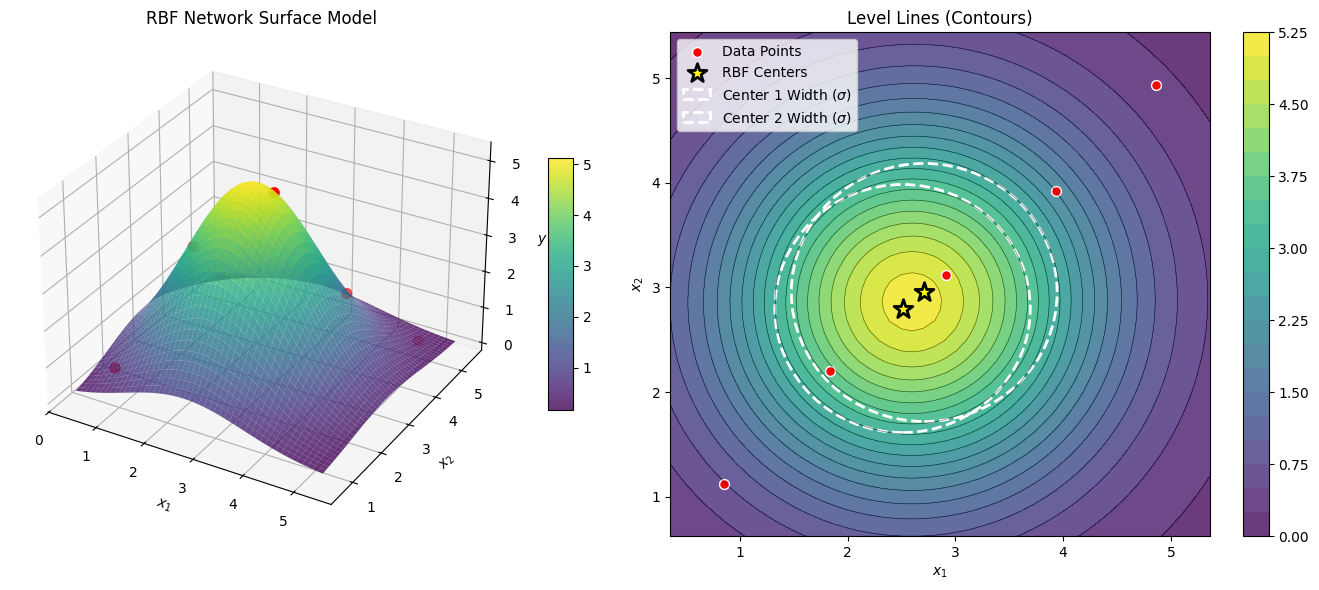

In [15]:
# ==============================================================================
# 4. PLOT MODEL SURFACE AND LEVEL LINES
# ==============================================================================
print("\n" + "="*60)
print("GENERATING PLOTS")
print("="*60)

# Create grid for surface plot
x1_min, x1_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
x2_min, x2_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 50), np.linspace(x2_min, x2_max, 50))
X_grid = np.column_stack([xx1.ravel(), xx2.ravel()])
y_grid = model.predict(X_grid).reshape(xx1.shape)

# Plotting
fig = plt.figure(figsize=(14, 6))

# 3D Surface
ax1 = fig.add_subplot(121, projection='3d')
surf = ax1.plot_surface(xx1, xx2, y_grid, cmap='viridis', alpha=0.8, edgecolor='none')
ax1.scatter(X[:, 0], X[:, 1], y, c='red', s=50, marker='o', label='Data Points')
ax1.set_xlabel('$x_1$')
ax1.set_ylabel('$x_2$')
ax1.set_zlabel('$y$')
ax1.set_title('RBF Network Surface Model')
fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=10)

# 2D Contours (Level Lines)
ax2 = fig.add_subplot(122)
contour = ax2.contourf(xx1, xx2, y_grid, levels=20, cmap='viridis', alpha=0.8)
ax2.contour(xx1, xx2, y_grid, levels=20, colors='black', linewidths=0.5, alpha=0.5)
ax2.scatter(X[:, 0], X[:, 1], c='red', s=50, marker='o', edgecolors='white', label='Data Points')

# Plot Centers
ax2.scatter(model.centers[:, 0], model.centers[:, 1], c='yellow', s=200, marker='*', 
            edgecolors='black', linewidths=2, label='RBF Centers')

# Plot Widths as circles
for i, (c, w) in enumerate(zip(model.centers, model.widths)):
    circle = plt.Circle(c, w, color='white', fill=False, linestyle='--', linewidth=2, 
                        label=f'Center {i+1} Width ($\sigma$)')
    ax2.add_patch(circle)

ax2.set_xlabel('$x_1$')
ax2.set_ylabel('$x_2$')
ax2.set_title('Level Lines (Contours)')
ax2.legend(loc='upper left')
fig.colorbar(contour, ax=ax2)

plt.tight_layout()
plt.savefig('rbf_model_plot.png', dpi=300)
plt.show()

In [16]:
# ==============================================================================
# 5. FINAL EVALUATION
# ==============================================================================
print("\n" + "="*60)
print("FINAL EVALUATION")
print("="*60)
y_final = model.predict(X)
print(f"{'Sample':<10}{'Actual':<10}{'Predicted':<10}{'Error':<10}")
print("-" * 40)
for i in range(len(y)):
    err = abs(y[i] - y_final[i])
    print(f"{i:<10}{y[i]:<10.4f}{y_final[i]:<10.4f}{err:<10.4f}")

print(f"\nFinal Model Equation Approximation:")
print(f"y = {model.bias:.4f} + ")
for i in range(model.n_hidden):
    c1, c2 = model.centers[i]
    w = model.weights[i]
    s = model.widths[i]
    print(f"    {w:.4f} * exp(-((x1-{c1:.4f})^2 + (x2-{c2:.4f})^2) / (2*{s:.4f}^2)) + ")


FINAL EVALUATION
Sample    Actual    Predicted Error     
----------------------------------------
0         0.7300    0.7327    0.0027    
1         3.6500    3.6486    0.0014    
2         4.8600    4.8609    0.0009    
3         2.0000    1.9994    0.0006    
4         0.3200    0.3185    0.0015    

Final Model Equation Approximation:
y = 0.1058 + 
    2.7715 * exp(-((x1-2.5082)^2 + (x2-2.7985)^2) / (2*1.1862^2)) + 
    2.2831 * exp(-((x1-2.7098)^2 + (x2-2.9521)^2) / (2*1.2339^2)) + 


$\frac{\partial L}{\partial w_j} = \frac{2}{N} \sum_{i=1}^N e_i \cdot \phi_{ij}$

$\frac{\partial L}{\partial b} = \frac{2}{N} \sum_{i=1}^N e_i$

$\frac{\partial L}{\partial \sigma_j} = \frac{2}{N} \sum_{i=1}^N e_i \cdot w_j \cdot \phi_{ij} \cdot \frac{||X_i - c_j||^2}{\sigma_j^3}$

$\frac{\partial L}{\partial c_j} = \frac{2}{N} \sum_{i=1}^N e_i \cdot w_j \cdot \phi_{ij} \cdot \frac{X_i - c_j}{\sigma_j^2}$